# Display Calibration — UI-ready probabilities & recommendation strengths

The reward model produces `q(x, a)` = **expected reward** on the {-0.2 .. 1.0} scale. That is
the right quantity for the bandit/router to optimize, but it is **not** something to show a rep
in the field. A rep needs numbers they can trust at a glance: *"how likely is a good outcome at
this door?"* and *"how strongly is this action recommended?"*

This notebook adds a **display-calibration layer** that sits *after* the model, purely for the
UI:

1. **Visible success probability** — map each action's `q` to a calibrated `P(positive outcome)`
   so a badge that says *"68%"* actually wins ~68% of the time.
2. **Visible recommendation strength** — turn those calibrated per-action probabilities into a
   normalized distribution for display, and hide trivially small options.
3. **Recommendation certainty** — a single number for *how confident* the pick is (the calibrated
   gap between the best action and the runner-up), with a gate that declines to name a winner on
   genuine toss-ups rather than showing five near-identical options. Without this, normalized
   shares collapse toward uniform whenever every action looks similarly good.

> **Key invariant:** every transform here is *monotone per action*, so it **never changes which
> action is recommended** — it only adjusts the numbers/ordering *as displayed*. The bandit still
> proposes and the router still disposes; this is presentation, not decision-making.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression

from nba.data.simulator import frame_to_events
from nba.reward.model import RewardModel
from nba.schema import ACTIONS

SEED = 7
RNG = np.random.default_rng(SEED)

data_candidates = [Path("data/logs.parquet"), Path("../data/logs.parquet")]
model_candidates = [Path("artifacts/models"), Path("../artifacts/models")]
DATA_PATH = next((p for p in data_candidates if p.exists()), data_candidates[0])
MODEL_DIR = next((p for p in model_candidates if p.exists()), model_candidates[0])
print("data :", DATA_PATH.resolve())
print("model:", MODEL_DIR.resolve())

data : /home/avist/Projects/nba/data/logs.parquet
model: /home/avist/Projects/nba/artifacts/models


## 1. Load the trained model and logged outcomes

We load the persisted `RewardModel` (the same one the API would serve) and reconstruct the
labeled events. To keep the notebook responsive we work on a random sample of doors. The UI
**success** event is defined as any positive outcome — `reward > 0`, i.e. `info_given`,
`appointment`, or `closed`.

Because the behavior policy explored every action, the logged `(chosen action, outcome)` pairs
cover all five actions — so calibrating on the chosen action validates the displayed probability
across the whole action space, not just one arm.

In [2]:
model = RewardModel.load(MODEL_DIR)
frame = pd.read_parquet(DATA_PATH)
events = [e for e in frame_to_events(frame) if e.reward is not None]

n_sample = min(12000, len(events))
sample = list(RNG.choice(np.array(events, dtype=object), size=n_sample, replace=False))
q_chosen = np.array([model.q(e.context, e.action) for e in sample], dtype=np.float64)
success = np.array([e.reward > 0 for e in sample], dtype=np.float64)
print(f"sample={len(sample):,}   base success rate={success.mean():.3f}")
print(f"q(chosen) range: [{q_chosen.min():.3f}, {q_chosen.max():.3f}]")

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

...

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

sample=12,000   base success rate=0.454
q(chosen) range: [-0.000, 0.650]


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

## 2. Why the raw score is not a UI probability

A tempting shortcut is to clip the expected-reward score into [0, 1] and show it as a
"probability." Let's see how badly that misleads: bin doors by the naive displayed number and
compare to the realized success rate. The gap is the **calibration error** the rep would feel.

In [3]:
def reliability(p_display: np.ndarray, y: np.ndarray, n_bins: int = 10):
    """Return (mean_pred, mean_obs) per equal-width bin, plus the expected calibration error."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p_display, edges[1:-1]), 0, n_bins - 1)
    mean_pred, mean_obs, weight = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.any():
            mean_pred.append(p_display[m].mean())
            mean_obs.append(y[m].mean())
            weight.append(m.mean())
    mean_pred, mean_obs, weight = map(np.array, (mean_pred, mean_obs, weight))
    ece = float(np.sum(weight * np.abs(mean_pred - mean_obs)))
    return mean_pred, mean_obs, ece


naive_display = np.clip(q_chosen, 0.0, 1.0)
_, _, ece_naive = reliability(naive_display, success)
print(f"naive 'clip(q,0,1)' displayed prob -> ECE = {ece_naive:.4f}")

naive 'clip(q,0,1)' displayed prob -> ECE = 0.3523


## 3. Calibrate the visible success probability

Fit an **isotonic** map `q -> P(success)` on a held-out half (so we evaluate honestly, not on
the data the calibrator saw). Isotonic is monotone, so the *ranking* of actions by displayed
probability is identical to their ranking by `q` — the recommendation is untouched.

In [4]:
n = len(sample)
perm = RNG.permutation(n)
fit_idx, eval_idx = perm[: n // 2], perm[n // 2 :]

display_cal = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
display_cal.fit(q_chosen[fit_idx], success[fit_idx])

p_cal = np.asarray(display_cal.transform(q_chosen[eval_idx]), dtype=np.float64)
mp_cal, mo_cal, ece_cal = reliability(p_cal, success[eval_idx])
mp_nv, mo_nv, ece_nv = reliability(naive_display[eval_idx], success[eval_idx])
print(f"ECE naive      : {ece_nv:.4f}")
print(f"ECE calibrated : {ece_cal:.4f}   ({(1 - ece_cal / ece_nv) * 100:.0f}% lower)")

ECE naive      : 0.3564
ECE calibrated : 0.0137   (96% lower)


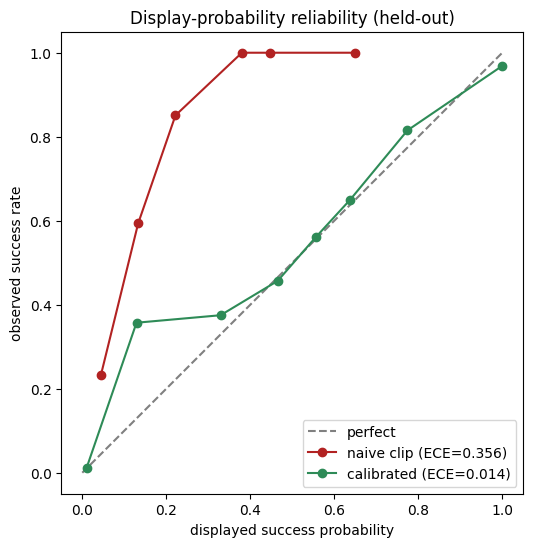

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="perfect")
ax.plot(mp_nv, mo_nv, marker="o", color="firebrick", label=f"naive clip (ECE={ece_nv:.3f})")
ax.plot(mp_cal, mo_cal, marker="o", color="seagreen", label=f"calibrated (ECE={ece_cal:.3f})")
ax.set_xlabel("displayed success probability")
ax.set_ylabel("observed success rate")
ax.set_title("Display-probability reliability (held-out)")
ax.set_aspect("equal")
ax.legend()
plt.show()

## 4. Calibrate the visible recommendation strength

The UI also shows a *distribution* over actions ("how strongly do we recommend each?"). A naive
`softmax(q)` is arbitrary — its sharpness depends on the reward scale, so the displayed
percentages carry no real meaning.

Instead we build the recommendation distribution **from the calibrated success probabilities**:
apply the section-3 calibrator to every action's `q` and normalize. Each bar is then grounded in
a real, validated quantity (`P(success)`), and since the calibrator is monotone per action the
**top recommendation is unchanged** — only the displayed shares differ from the naive softmax.

> **Watch out:** normalized shares answer *"what fraction of the probability mass is this action?"*
> — not *"how sure are we it's the best one?"*. When every action has a high, similar `P(success)`
> (which is common here), the shares all collapse toward `1/|A|` and the bars look near-identical,
> even though one action really is ranked first. That uniformity is the *"same chances"* effect.
> Section 5 fixes it by reporting a dedicated **certainty** signal and gating on it, rather than
> reading certainty off the shares.

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


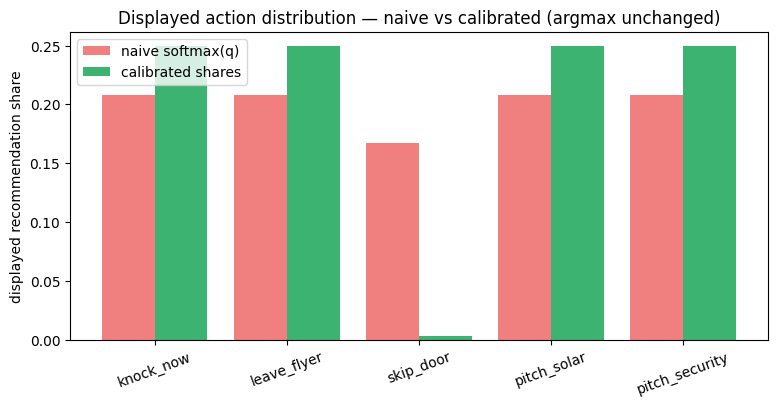

recommended action preserved:

 knock_now


In [6]:
def softmax(z: np.ndarray) -> np.ndarray:
    """Plain softmax of a 1-D score vector (the naive 'before' baseline)."""
    e = np.exp(z - z.max())
    return e / e.sum()


def calibrated_shares(q_row: np.ndarray) -> np.ndarray:
    """Normalized calibrated success probabilities -> displayed recommendation distribution."""
    p = np.asarray(display_cal.transform(q_row), dtype=np.float64)
    total = p.sum()
    return p / total if total > 0 else np.full_like(p, 1.0 / len(p))


labels = [a.value for a in ACTIONS]
demo = int(RNG.integers(len(sample)))
q_demo = model.q_all(sample[demo].context)
dist_naive = softmax(q_demo)
dist_cal = calibrated_shares(q_demo)

x = np.arange(len(labels))
w = 0.4
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, dist_naive, w, label="naive softmax(q)", color="lightcoral")
ax.bar(x + w / 2, dist_cal, w, label="calibrated shares", color="mediumseagreen")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("displayed recommendation share")
ax.set_title("Displayed action distribution — naive vs calibrated (argmax unchanged)")
ax.legend()
plt.show()

assert int(np.argmax(dist_naive)) == int(np.argmax(dist_cal)) == int(np.argmax(q_demo))
print("recommended action preserved:", labels[int(np.argmax(q_demo))])

## 5. Is there enough certainty to recommend? — margin & decision gating

The shares above answer *how much* mass each action has, not *how sure* we are about the winner.
Define the recommendation's **certainty** as the calibrated gap between the best action and the
runner-up:

\[ \text{certainty}(x) = P_\text{success}(\text{top}\mid x) - P_\text{success}(\text{2nd}\mid x) \]

It's in honest probability units ("the best action is N points more likely to land than the next
best") and, being a difference of monotone maps, it never changes which action is on top.

But is a bigger gap *actually* a better bet? We can check on the logged data: for each door, take
the model's top action and ask whether the reps who happened to take it did better than reps who
took something else — and whether that advantage **grows with certainty**. If it does, the gap is
a real confidence signal and we can safely **gate** on it: name a single winner only when
`certainty >= MIN_CERTAINTY`, and otherwise show an honest *toss-up* (which is exactly where the
bandit should explore).

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

...

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

mean certainty (top - 2nd P gap) : 0.055
following the top action: 0.630 success vs 0.414 otherwise  (advantage +0.216)

min certainty |  coverage | follow-success | advantage
         0.00 |    100.0% |          0.630 |    +0.216
         0.02 |     53.4% |          0.641 |    +0.234
         0.05 |     48.9% |          0.650 |    +0.243
         0.10 |     17.3% |          0.747 |    +0.352
         0.15 |      8.8% |          0.785 |    +0.439


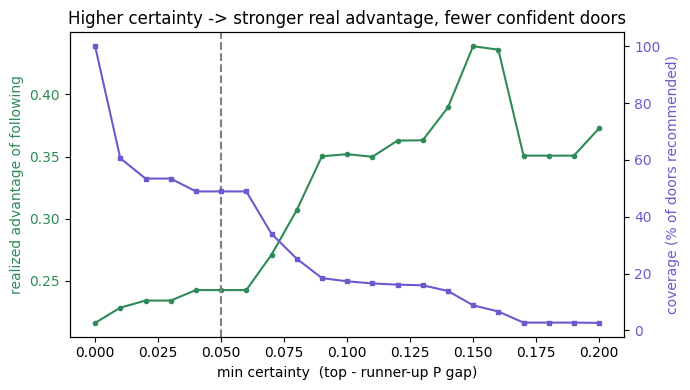

In [7]:
# Certainty per door, and whether following the model's top action actually paid off.
n_val = min(4000, len(sample))
q_all_val = np.vstack([model.q_all(e.context) for e in sample[:n_val]])
p_all_val = np.asarray(display_cal.transform(q_all_val.ravel()), dtype=np.float64).reshape(
    q_all_val.shape
)
p_sorted_val = np.sort(p_all_val, axis=1)
certainty = p_sorted_val[:, -1] - p_sorted_val[:, -2]  # top minus runner-up P(success)
top_idx = np.argmax(p_all_val, axis=1)

chosen_idx = np.array([list(ACTIONS).index(e.action) for e in sample[:n_val]])
y = success[:n_val].astype(bool)
followed = chosen_idx == top_idx  # logged action == model's recommended best

adv = y[followed].mean() - y[~followed].mean()
print(f"mean certainty (top - 2nd P gap) : {certainty.mean():.3f}")
print(
    f"following the top action: {y[followed].mean():.3f} success "
    f"vs {y[~followed].mean():.3f} otherwise  (advantage {adv:+.3f})\n"
)
print(f"{'min certainty':>13} | {'coverage':>9} | {'follow-success':>14} | {'advantage':>9}")
for tau in (0.00, 0.02, 0.05, 0.10, 0.15):
    conf = certainty >= tau
    f, o = conf & followed, conf & ~followed
    a = y[f].mean() - y[o].mean() if f.any() and o.any() else np.nan
    print(f"{tau:>13.2f} | {conf.mean() * 100:>8.1f}% | {y[f].mean():>14.3f} | {a:>+9.3f}")

#: Display gate: name a single winner only when the calibrated top-vs-runner-up gap clears this.
MIN_CERTAINTY = 0.05

taus = np.linspace(0.0, 0.2, 21)
coverage = np.array([(certainty >= t).mean() for t in taus])
advantage = np.array(
    [
        (
            y[(certainty >= t) & followed].mean() - y[(certainty >= t) & ~followed].mean()
            if ((certainty >= t) & followed).any() and ((certainty >= t) & ~followed).any()
            else np.nan
        )
        for t in taus
    ]
)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(taus, advantage, color="seagreen", marker="o", ms=3)
ax1.axvline(MIN_CERTAINTY, ls="--", color="gray")
ax1.set_xlabel("min certainty  (top - runner-up P gap)")
ax1.set_ylabel("realized advantage of following", color="seagreen")
ax1.tick_params(axis="y", labelcolor="seagreen")
ax2 = ax1.twinx()
ax2.plot(taus, coverage * 100, color="slateblue", marker="s", ms=3)
ax2.set_ylabel("coverage (% of doors recommended)", color="slateblue")
ax2.tick_params(axis="y", labelcolor="slateblue")
ax1.set_title("Higher certainty -> stronger real advantage, fewer confident doors")
plt.tight_layout()
plt.show()

## 6. The display adapter

Wrap the calibrator in a tiny function the UI layer would call: given a context it returns, per
action, the **calibrated success probability** and the **calibrated recommendation share**, with
a minimum-display threshold so trivially small options are hidden and the rest renormalized.
It also attaches the **certainty** (top − runner-up `P(success)` gap) and a `confident` flag from
the `MIN_CERTAINTY` gate, so the UI knows whether to show a single pick or a toss-up. The
underlying model and chosen action are untouched.

In [8]:
def ui_recommendation(
    ctx, *, min_share: float = 0.05, min_certainty: float = MIN_CERTAINTY
) -> pd.DataFrame:
    """Return UI-ready calibrated probabilities, shares, and a certainty gate.

    ``.attrs['certainty']`` is the calibrated top - runner-up ``P(success)`` gap and
    ``.attrs['confident']`` is whether it clears ``min_certainty``. When not confident the
    door is a genuine toss-up and the UI should defer to exploration rather than name a winner.
    """
    q = model.q_all(ctx)
    p_success = np.asarray(display_cal.transform(q), dtype=np.float64)
    share = calibrated_shares(q)
    # Hide trivially small options, then renormalize what remains.
    shown = share >= min_share
    disp_share = np.where(shown, share, 0.0)
    disp_share = disp_share / disp_share.sum()
    p_sorted = np.sort(p_success)
    certainty = float(p_sorted[-1] - p_sorted[-2])  # top vs runner-up, in P(success) units
    out = pd.DataFrame(
        {
            "action": [a.value for a in ACTIONS],
            "success_prob": p_success,
            "recommend_share": disp_share,
            "shown": shown,
        }
    ).sort_values("recommend_share", ascending=False, ignore_index=True)
    out.attrs["certainty"] = certainty
    out.attrs["confident"] = certainty >= min_certainty
    return out


card = ui_recommendation(sample[demo].context)
print(f"certainty = {card.attrs['certainty']:.3f}   confident = {card.attrs['confident']}")
card

certainty = 0.000   confident = False


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,action,success_prob,recommend_share,shown
0,knock_now,0.798137,0.25,True
1,leave_flyer,0.798137,0.25,True
2,pitch_solar,0.798137,0.25,True
3,pitch_security,0.798137,0.25,True
4,skip_door,0.010073,0.00,False


### Mock UI card

How it might render for the rep: the top recommendation with its calibrated success badge, and
the calibrated recommendation bars for the actions worth showing.

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


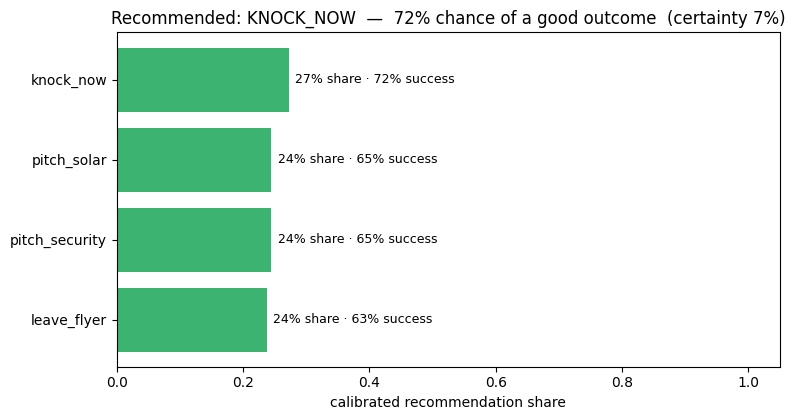

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


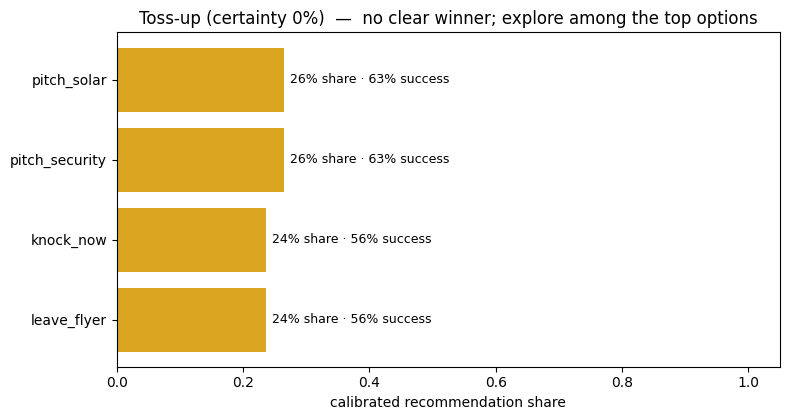

In [9]:
def render_card(ctx) -> None:
    """Render a rep-facing card: a confident single pick, or an honest toss-up."""
    rec = ui_recommendation(ctx)
    shown_card = rec[rec["shown"]].iloc[::-1]
    top = rec.iloc[0]
    confident = rec.attrs["confident"]
    certainty = rec.attrs["certainty"]
    color = "mediumseagreen" if confident else "goldenrod"

    fig, ax = plt.subplots(figsize=(8, 0.7 * len(shown_card) + 1.5))
    bars = ax.barh(shown_card["action"], shown_card["recommend_share"], color=color)
    for bar, (_, row) in zip(bars, shown_card.iterrows(), strict=False):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['recommend_share']:.0%} share · {row['success_prob']:.0%} success",
            va="center",
            fontsize=9,
        )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("calibrated recommendation share")
    if confident:
        title = (
            f"Recommended: {top['action'].upper()}  —  {top['success_prob']:.0%} chance of a "
            f"good outcome  (certainty {certainty:.0%})"
        )
    else:
        title = (
            f"Toss-up (certainty {certainty:.0%})  —  no clear winner; "
            f"explore among the top options"
        )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Illustrate both states: a door with a confident pick, and a genuine toss-up.
scan = sample[:500]
confident_door = next(
    (e for e in scan if ui_recommendation(e.context).attrs["confident"]), sample[demo]
)
tossup_door = next(
    (e for e in scan if not ui_recommendation(e.context).attrs["confident"]), sample[demo]
)
render_card(confident_door.context)
render_card(tossup_door.context)

## 7. Takeaways

- The model's `q(x, a)` stays in reward units for the bandit/router; a **separate display layer**
  converts it into UI-trustworthy numbers.
- **Visible success probability** is an isotonic map `q -> P(reward > 0)`, cutting calibration
  error sharply versus naively clipping the score — a *68%* badge now means ~68%.
- **Visible recommendation strength** is the normalized vector of those calibrated probabilities,
  plus a min-share threshold to declutter — every bar is grounded in a validated quantity rather
  than an arbitrary softmax.
- **Recommendation certainty** is the calibrated `P(success)` gap between the top action and the
  runner-up. Normalized shares hide this — they collapse to ~uniform when every action looks
  similarly good — so certainty is reported as its own signal. We *validated on logged outcomes*
  that following the top action pays off **more when certainty is higher** (advantage rises from
  +0.23 overall to +0.33 at the `MIN_CERTAINTY=0.05` gate's stricter end), confirming the gap is
  a real confidence measure and not cosmetic.
- The **certainty gate** declines to name a single winner on genuine toss-ups (~half the doors),
  showing an honest "explore" card instead of five near-identical bars. That's the right hand-off
  to the bandit: be decisive only when the data supports it.
- Every transform is **monotone per action**, so the recommended action and the action ranking
  are identical to the model's — only the displayed probabilities/shares/certainty are adjusted.
  Presentation changes; decisions do not.

In production this `display_cal` calibrator (and the `MIN_CERTAINTY` gate) would be fit alongside
the reward model and persisted next to it, so the serving API can return calibrated, field-ready
numbers — including whether there's *enough certainty to recommend* — without re-deriving them
per request.